In this module:
-  Learn about other packages to use for data visualization in Python,  such as:
  - Seaborn
  - Plotly (for interactive vis)
  - Wordclouds and Venn Diagrams
- Discuss when to use (and when not to use) interactive data visualization


# Install and load packages
- After installing seaborn, I can load all the packages I'll be using in this lesson

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
import PIL
import requests

## Load data
- I'm going to work with the 'tips' sample dataset, which is available as part of the seaborn (sns) package
- This dataset contains information about tips at a restaurant, including  meal time, party size, gender of customer, total bill amount, and tip amount

In [3]:
tips = sns.load_dataset('tips')
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


# Basic plot
- Let's make a simple line plot of tip amount vs total bill

<Axes: xlabel='total_bill', ylabel='tip'>

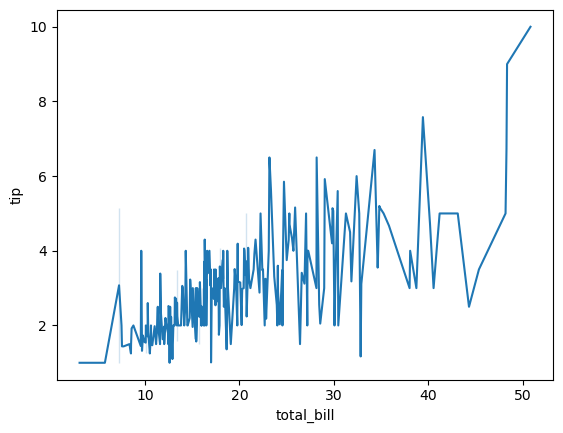

In [4]:
# Basic line plot
sns.lineplot(data = tips, # Choose our dataset
             x = 'total_bill', # define our x variable
             y = 'tip',) # define our y variable

# Use premade styles
-  I can use premade styles to alter the appearance of the plot
- Try other preset  styles like 'darkgrid', 'whitegrid', 'dark', 'white',  'ticks', then make the line plot again  - how has it changed?

<Axes: xlabel='total_bill', ylabel='tip'>

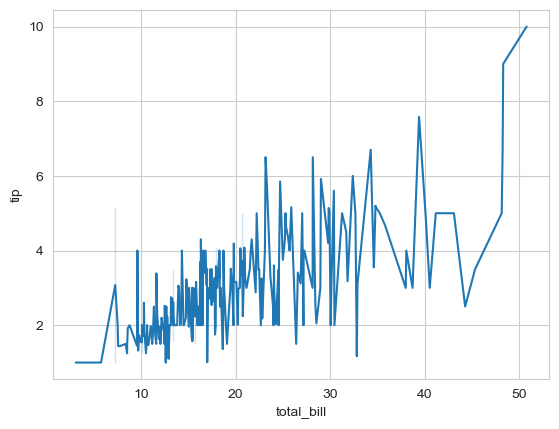

In [5]:
# Basic line plot
sns.set_style('whitegrid')
sns.lineplot(data = tips, # Choose our dataset
             x = 'total_bill', # define our x variable
             y = 'tip',) # define our y variable


## Add titles and axis labels
- Seaborn can do many of the same things as matplotlib, like adding labels. 
- I do this using the **set.** function

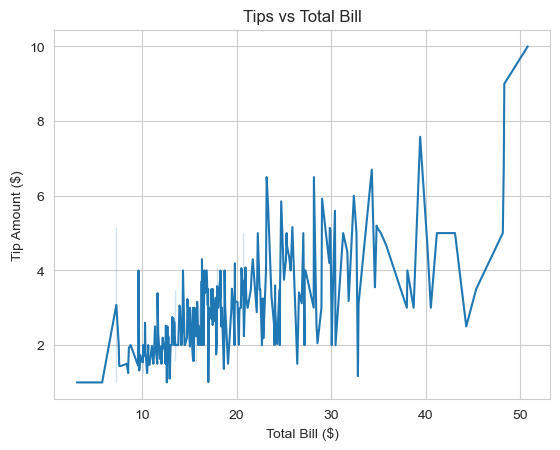

In [6]:
# Basic line plot
tipgraph = sns.lineplot(data = tips, # Choose our dataset
             x = 'total_bill', # define our x variable
             y = 'tip',) # define our y variable
tipgraph.set(title = 'Tips vs Total Bill',
            xlabel = 'Total Bill ($)',
            ylabel = 'Tip Amount ($)')
plt.show()

## Modify aesthetic elements
- Like in base matplotlib, I can use the subplots function to change figure size
-  I can also change colour, marker style, and line style

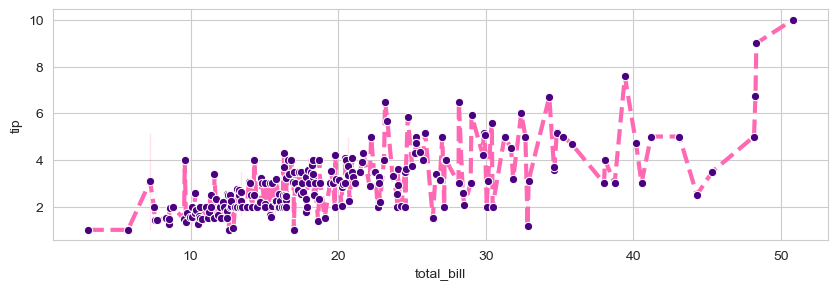

In [7]:
fig = plt.subplots(figsize = (10, 3))
tipgraph = sns.lineplot(data = tips, # Choose our dataset
             x = 'total_bill', # define our x variable
             y = 'tip', # define our y variable
             color = 'hotpink', # change the color of the line
             linestyle = '--', # change the line style'
             linewidth = 3, # change the line width
             marker = 'o', # change the marker
             markerfacecolor = 'indigo',) # change the marker face color
plt.show()

# Add multiple variables
- Seaborn makes it very easy to represent multiple variables with different visual elements of the graph

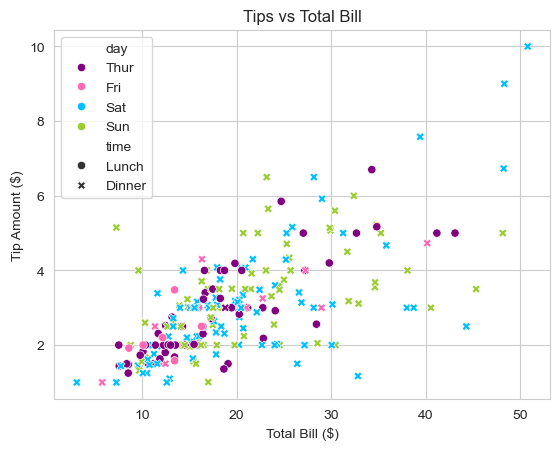

In [8]:

tipgraph = sns.scatterplot(data = tips, # Choose our dataset
                x = 'total_bill', # define our x variable
                y = 'tip', # define our y variable
                style= 'time', # define the style variable
                hue = 'day', # define the hue variable
                palette= ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])
tipgraph.set(title = 'Tips vs Total Bill',
                   xlabel = 'Total Bill ($)',
                   ylabel = 'Tip Amount ($)')
plt.show()

### Pairplot
- **pairplot** is another convenient way to compare variables

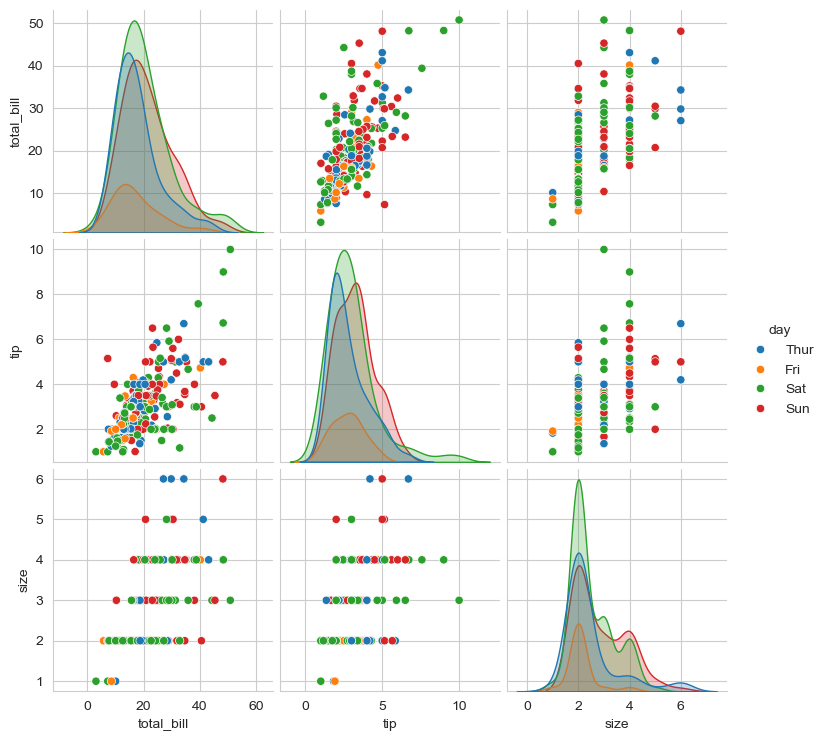

In [9]:
sns.pairplot(data = tips,
             hue = 'day')

### Relplot
- **relplot** also lets us explore specific levels within variables

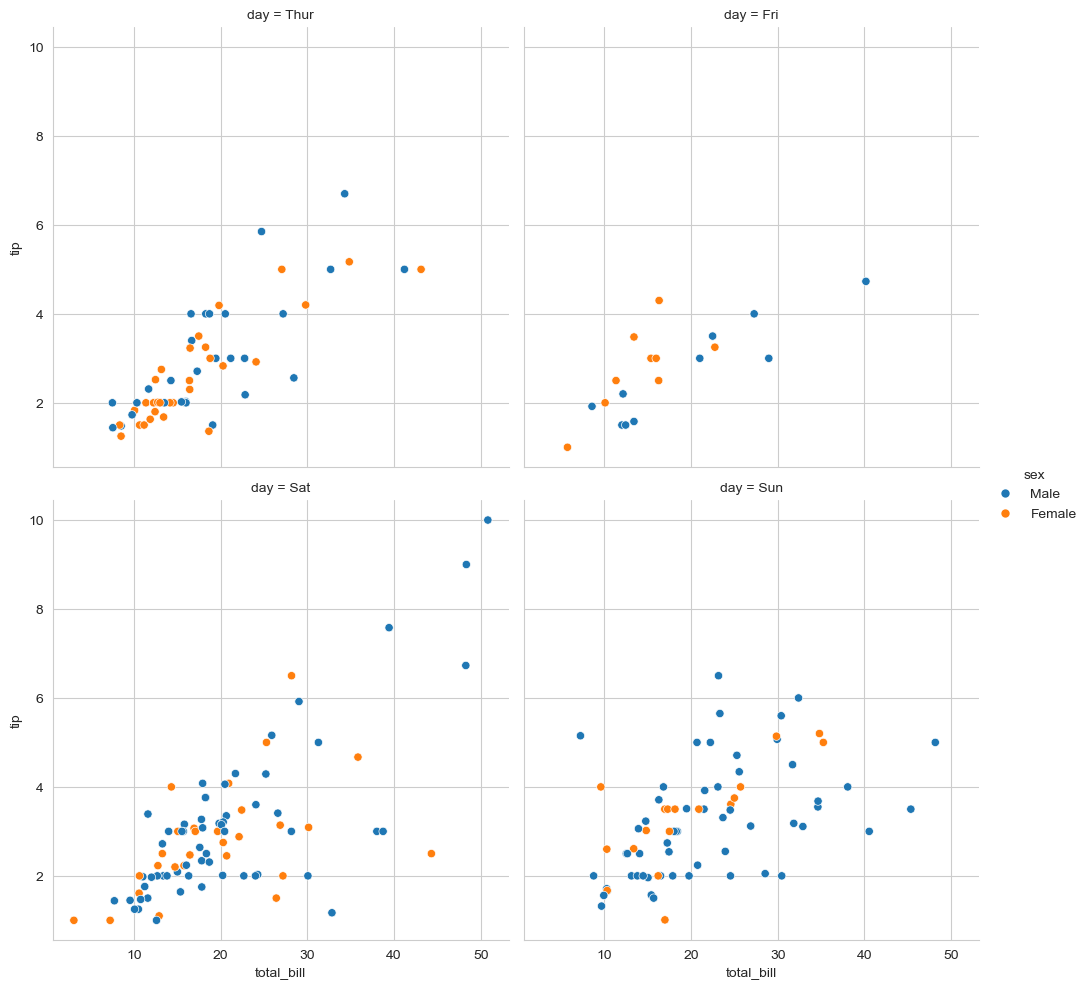

In [10]:
daysplot = sns.relplot(data = tips, # Choose our dataset
                x = 'total_bill', # define our x variable
                y = 'tip', # define our y variable
                hue = 'sex', # define the hue variable
                col = 'day', # define the column variable
                kind = 'scatter', # define the kind of plot
                col_wrap = 2) # define the number of columns
plt.show()

### Seaborn resources:
- Datacamp has a seaborn cheatsheet that covers the basics:

   https://images.datacamp.com/image/upload/v1676302629/Marketing/Blog/Seaborn_Cheat_Sheet.pdf
-  Or look at the seaborn gallery: http://seaborn.pydata.org/examples/index.html

# Plotly
### Setting up
- First, let's import the package and make some sample data

In [11]:
import plotly.graph_objects as go     
# 'go' is 'graph objects’
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

### Making plot
- Plotle syntax is different from matplotlib/seaborn
- First, make the figure
- Next, choose the plot type (bar) and the data
- Next, update the layout to include titles
-  Finally, show the plot!

In [12]:
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))


In [13]:
graph = go.Figure()
# Next, chhose our plot type (bar) and our data
graph.add_trace(go.Bar(x=x1, y=y1))
#Next, update our layout to include titles
graph.update_layout(title_text='Pirate Scores',
                    xaxis_title = 'Pirates',
                    yaxis_title = 'Score')
# Finally, show our plot!
graph.show()

### Customizing plotly graphs

In [14]:
#Customizing plotly graphs
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', 
                           marker=dict(size=15, # point size
                                       color='hotpink',  # point colour
                                       opacity=1,  # point transparency/alpha
                                       line=dict(width=5, color='purple')  # point outline
                                       )))
graph.update_layout(title='Interactive Pirate Plot',
                    xaxis_title='Pirates',
                    yaxis_title='Scores',
                    width=500, height=500)

### Wordclouds and venn diagrams
- Import the **wordcloud** package and load the sample dataset of movie quotes

In [15]:
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv", on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


# Making wordclouds
- Weʼll make a simple word cloud using the ‘quoteʼ variable

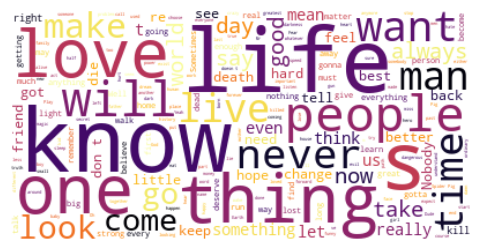

In [16]:
 # join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)
# generate our wordcloud image
wordcloud = WordCloud(background_color="white", colormap = 'inferno').generate(text)
# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, # remember 'imshow' from when we added pictures to our matplotlib axes
          interpolation='bilinear')   
ax.axis("off")
plt.show() 

# Making venn diagrams
 - We can use the matplotlib_venn extension to make venn diagrams
 - First import the package
 - Then define the sets

In [17]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# Making venn diagrams
 Next, assign the sets to each circle and modify the appearance

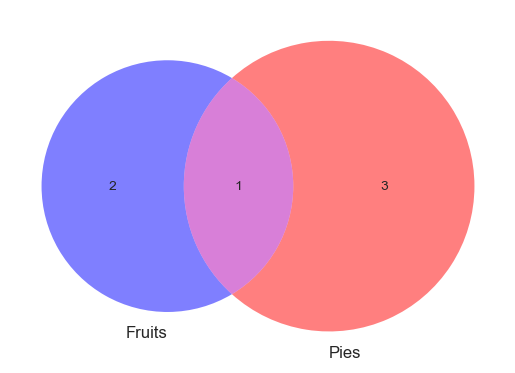

In [18]:
diagram = venn2([A, B],
                set_labels = ('Fruits', 'Pies'),
                set_colors=("blue", "red"),
                alpha=0.5)
plt.show()

### Modify venn diagrams

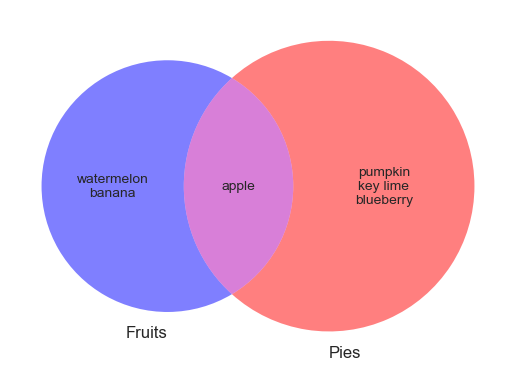

In [19]:
diagram = venn2([A, B],
                set_labels = ('Fruits', 'Pies'),
                set_colors=("blue", "red"),
                alpha=0.5)
diagram.get_label_by_id("10").set_text("\n".join(A - B))# left
diagram.get_label_by_id("11").set_text("\n".join(A & B))# middle
diagram.get_label_by_id("01").set_text("\n".join(B - A))# right
plt.show()
